10.validación cruzada 

In [78]:
# librerias 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import pandas as pd
import numpy as np


In [79]:
df = pd.read_parquet("data/listings_clean.parquet")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city,log_price
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas",4.584967
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas",5.081404
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas",3.663562
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas",4.983607
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas",4.077537


In [80]:
#variable categorica 
quantiles = df['price'].quantile([0, 0.33, 0.66, 1]).values

df['price_category'] = pd.cut(
    df['price'],
    bins=quantiles,
    labels=['Económica', 'Intermedia', 'Cara'],
    include_lowest=True
)

In [81]:
print(df['price_category'].value_counts())

price_category
Cara          25897
Económica     25185
Intermedia    25164
Name: count, dtype: int64


In [82]:
#Varible ccategórica 
df['price_category'] = pd.qcut(
    df['price'],
    q=3,
    labels=['Económica', 'Intermedia', 'Cara']
)

In [83]:
# variables y x 

y = df['price_category']

X = df.drop(columns=['price', 'price_category'])

X = X.select_dtypes(include=['number'])


In [84]:
#división para el train test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [85]:
#modelo base (árbol de clasificación)
modelo = DecisionTreeClassifier(max_depth=10, random_state=42)

modelo.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

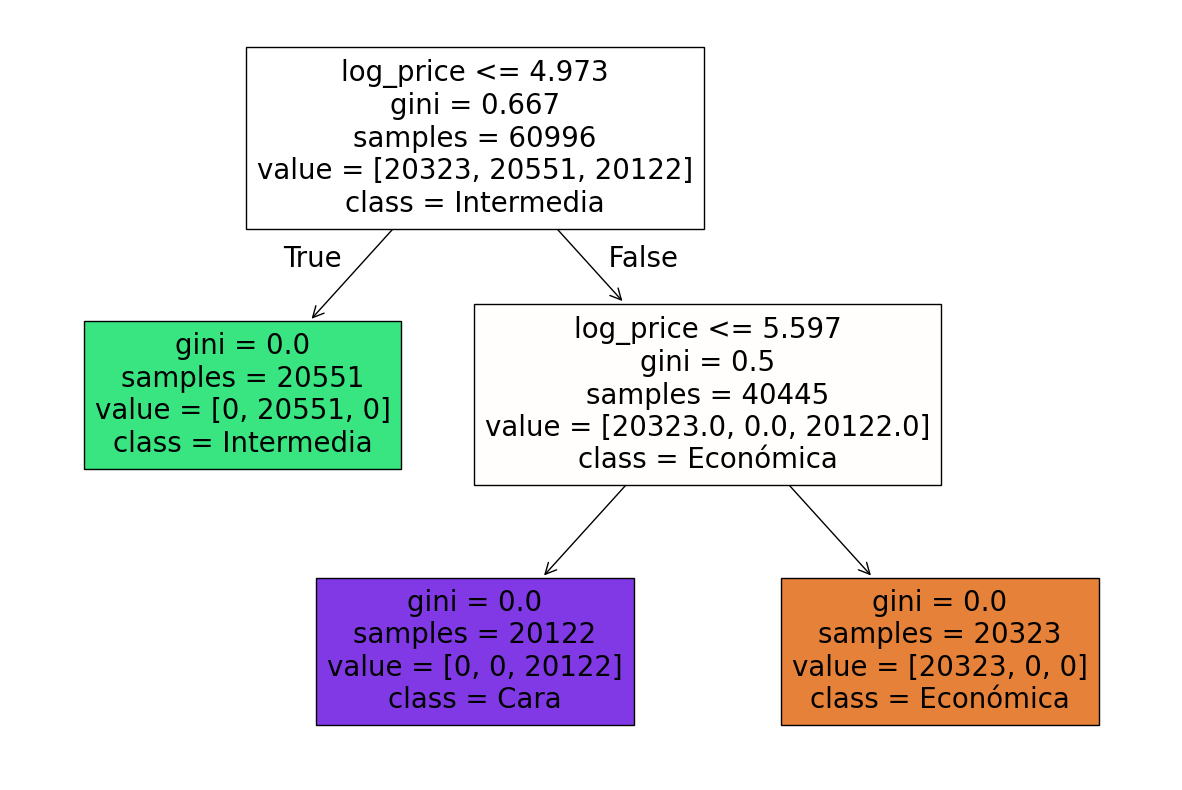

In [86]:
#arbol 


plt.figure(figsize=(15,10))
plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=['Económica', 'Intermedia', 'Cara'],
    filled=True
)
plt.show()

## Visualización del árbol de clasificación

Se visualizó el árbol de decisión generado para clasificar los alojamientos en categorías de precio. 

El modelo utiliza principalmente la variable `log_price` como criterio de decisión en los primeros niveles del árbol, lo que indica que esta variable tiene una alta capacidad para separar las clases.

Se observa que el árbol logra divisiones muy claras, alcanzando nodos con índice de Gini igual a 0, lo que significa que las observaciones en dichos nodos pertenecen a una sola clase.

Sin embargo, este comportamiento sugiere la posible presencia de fuga de información, ya que `log_price` está directamente relacionada con la variable objetivo (`price_category`). Esto provoca que el modelo aprenda patrones demasiado evidentes y no realistas.

In [87]:
#evaluación en el test 
y_pred = modelo.predict(X_test)

print("Accuracy en test:", accuracy_score(y_test, y_pred))

Accuracy en test: 1.0


## Evaluación del modelo en el conjunto de prueba

El modelo de árbol de clasificación obtuvo un accuracy de **1.00** en el conjunto de prueba.

Este resultado indica que el modelo clasificó correctamente el 100% de las observaciones. Sin embargo, un desempeño perfecto suele ser indicio de sobreajuste o fuga de información.

En este caso, el uso de la variable `log_price`, derivada directamente del precio, permite al modelo realizar predicciones prácticamente exactas, lo cual no refleja un comportamiento realista en un escenario práctico.

In [88]:
#validación cruzada 
scores = cross_val_score(
    modelo,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

In [89]:
#resultados 
print("Accuracy por fold:", scores)
print("Accuracy promedio:", np.mean(scores))
print("Desviación estándar:", np.std(scores))

Accuracy por fold: [1. 1. 1. 1. 1.]
Accuracy promedio: 1.0
Desviación estándar: 0.0


## Modelo con validación cruzada

Se aplicó validación cruzada con 5 particiones al modelo de árbol de clasificación para evaluar su capacidad de generalización.

El modelo obtuvo un accuracy promedio de **1.00**, con una desviación estándar de **0.00**, lo que indica un desempeño completamente consistente en todas las particiones.

Al comparar con el resultado obtenido en el conjunto de prueba (accuracy = 1.00), se observa que ambos valores son idénticos.

Este comportamiento confirma que el modelo no presenta variabilidad en su desempeño, lo cual refuerza la sospecha de fuga de información. Esto se debe a que la variable `log_price`, utilizada como predictor, está directamente relacionada con la variable objetivo.

Por lo tanto, aunque el modelo presenta un desempeño perfecto, este no es representativo de una capacidad real de generalización.

modelo sin fuga de información.Se entrenó un nuevo modelo de clasificación excluyendo la variable `log_price`, ya que esta esta directamente relacionada con la varible objetivo y genera una fuga de información. 


In [100]:
X = df.drop(columns=['price', 'price_category', 'log_price'])

In [101]:
#dejando solo numericas 
X = X.select_dtypes(include=[np.number])

In [102]:
#train test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [103]:
modelo = DecisionTreeClassifier(max_depth=10, random_state=42)
modelo.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

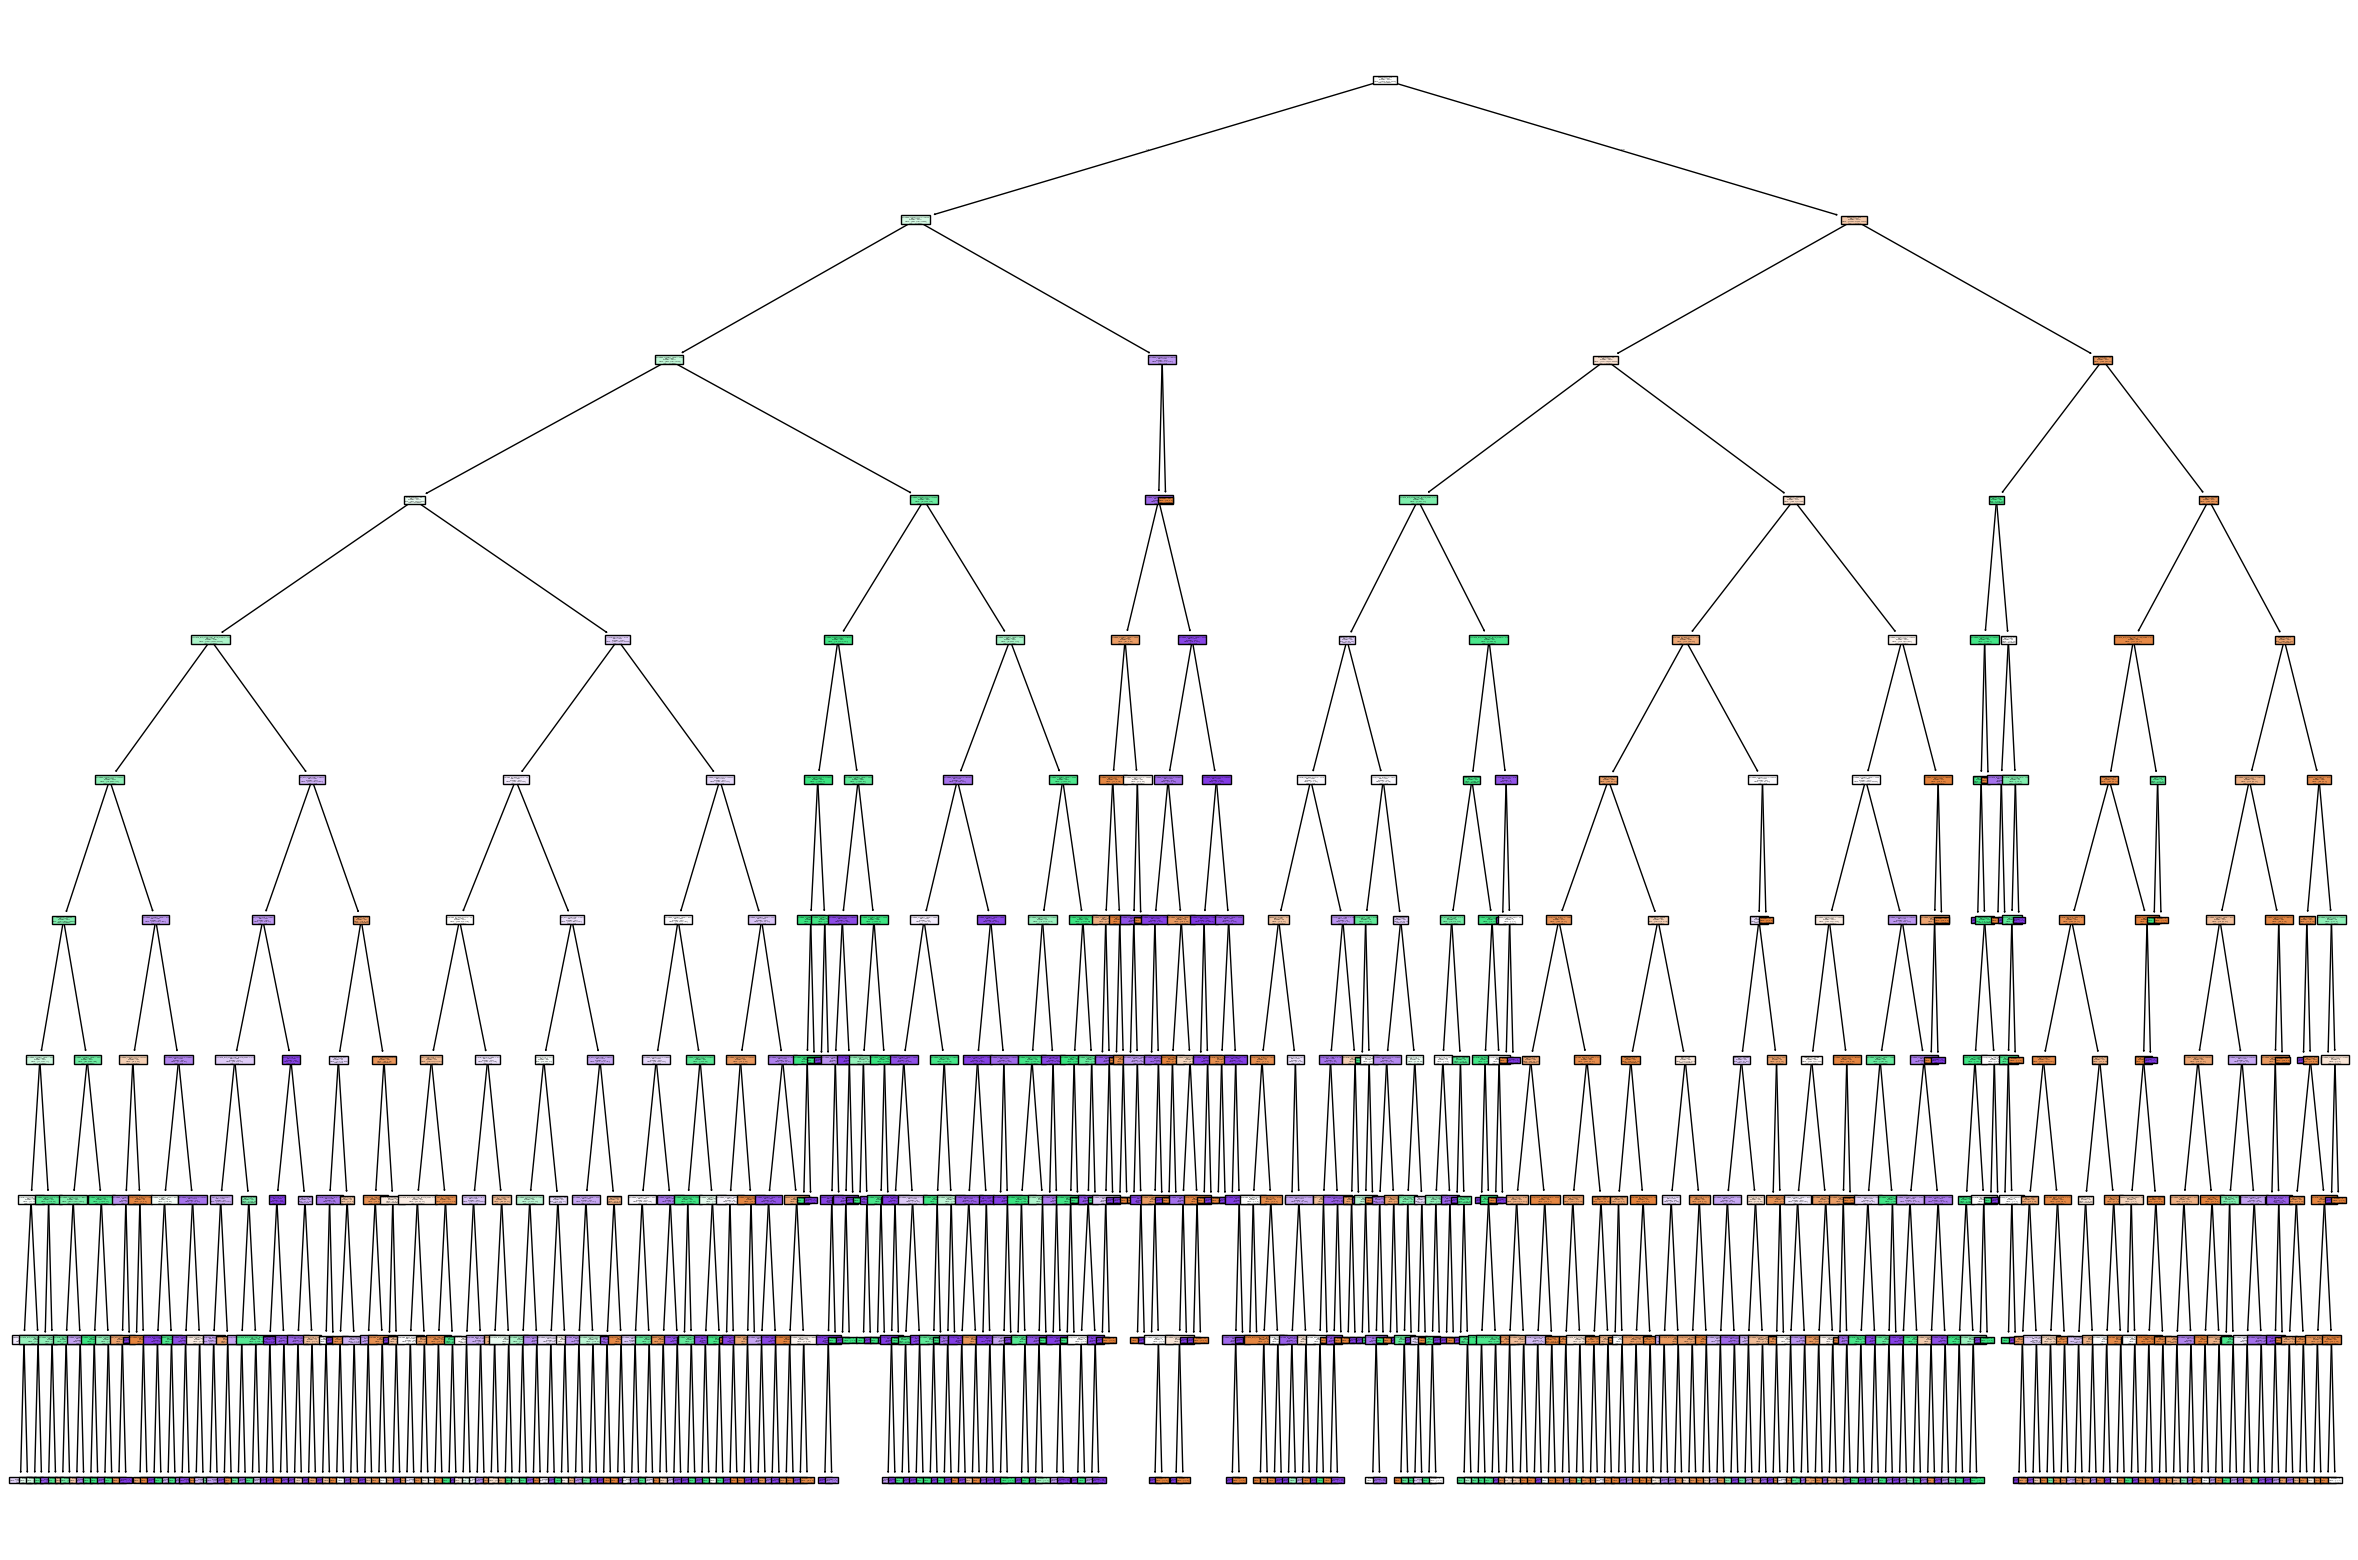

In [ ]:
plt.figure(figsize=(20,12))

plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=['Económica', 'Intermedia', 'Cara'],
    filled=True,
    max_depth=3   # 🔥 clave
)

plt.show()

In [104]:
#evaluacion del test 
y_pred = modelo.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred)
print("Accuracy en test:", accuracy_test)

Accuracy en test: 0.7866885245901639


In [106]:
#validacion cruzada 
scores = cross_val_score(
    modelo,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Accuracy promedio:", np.mean(scores))
print("Desviación estándar:", np.std(scores))

Accuracy promedio: 0.7810348819239415
Desviación estándar: 0.002817541392444696
